
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El texto de orientación de la plantilla entre corchetes todavía está presente aquí. Por favor, elimina todas las instrucciones entre corchetes antes de enviar, para que solo permanezca tu propia narrativa.

</div>


El propósito de este proyecto es el de determinar cuál de los dos planes que ofrece la compañía genera mayores ingresos. Esto es importante ya que el equipo de marketing necesita saber sobre cuál plan debe enfocar la publicidad. Lo primero que haré será:
1. Obtener los datos
2. Hacer una lipieza de ellos
3. Hacer una agregación en los datos para obtener la información que necesito analizar
4. Realizar el análisis estadístico sobre la muestra de 500 usuarios
5. Entregar una recomendación de negocio a partir de la inferencia estadística

<div class="alert alert-block alert-success">

# ¡Hola Ricardo!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión. Corregiré algunas imprecisiones de la review de Dot y te dejaré mis propias recomendaciones o felicitaciones. 

Un gusto acompañarte en este proceso, vamos a ello!

### Comentario General Iteración #2

Quiero dejarte aqui la apreciacion general del proyecto para que sepas en lo que debes enfocarte y luego vas punto por punto revisando mis recomendaciones. 

Respecto a tu trabajo en esta primera iteración, has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. Solo quedaron algunos puntos señalados donde hace falta reforzar el análisis propuesto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Inicialización

In [1]:
# Cargar todas las librerías
import scipy.stats as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La configuración de tu proyecto es fácil de seguir: objetivo claro, un plan de análisis concreto y pasos de inicialización/carga de datos limpios.

</div>


## Preparar los datos

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente: todavía hay texto guía de la plantilla entre corchetes. Por favor, elimina estas instrucciones entre corchetes en todo el notebook antes de la entrega final.

</div>


## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas

plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Me he encontrado lo siguiente:
1. Según el diccionario de datos la columna debe llamarse `usd_monthly_fee` pero en el dataframe se llama `usd_monthly_pay`
2. Los precios están dados por GB y no por MB por lo que necesito una columna adicional que convierta los mb_per_month_included a gb_per_month_included dividiendo los mb entre 1024.

## Corregir datos

In [5]:
plans = plans.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'})

## Enriquecer los datos

In [6]:
# Convierto los MB incluidos a GB incluidos (1 GB = 1024 MB)
# Verifico primero que la division sea exacta para no truncar valores en silencio
divisible = (plans['mb_per_month_included'] % 1024 == 0).all()
print('Todos los limites son multiplos exactos de 1024:', divisible)

plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
if divisible:
    plans['gb_per_month_included'] = plans['gb_per_month_included'].astype(int)

plans.info()

Todos los limites son multiplos exactos de 1024: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_fee        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   gb_per_month_included  2 non-null      int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 272.0+ bytes


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Al convertir los MB incluidos a GB incluidos, hacer un casting a `int` puede truncar valores de forma silenciosa. Aquí funciona porque los valores de MB incluidos son múltiplos exactos de 1024, pero es una buena práctica verificar la divisibilidad o evitar la truncación para no subestimar la cuota incluida en otros conjuntos de datos.

</div>


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios

users.sample(n=10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
46,1046,Beata,Hooper,67,"Boston-Cambridge-Newton, MA-NH MSA",2018-02-19,surf,NaN
100,1100,Aaron,Rowe,65,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-13,surf,NaN
472,1472,Maximo,Mendoza,51,"San Francisco-Oakland-Berkeley, CA MSA",2018-04-10,surf,NaN
259,1259,Etsuko,Perry,63,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-03-16,surf,NaN
403,1403,Jae,Gardner,27,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-02-06,ultimate,NaN
15,1015,Beata,Carpenter,26,"Pittsburgh, PA MSA",2018-12-05,surf,NaN
218,1218,Stanford,Pena,23,"Bakersfield, CA MSA",2018-01-16,surf,NaN
324,1324,Romana,Moore,18,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",2018-04-04,surf,NaN
396,1396,Ardelia,Benton,65,"Salt Lake City, UT MSA",2018-06-01,surf,NaN
16,1016,Jann,Salinas,30,"Fresno, CA MSA",2018-10-25,surf,NaN


In [9]:
# Imprime la cantidad de valores duplicados
print(users.duplicated().sum())

0


In [10]:
# Imprime la cantidad de nulos
print(users.isna().sum())

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


In [11]:
# Imprime los estadísticas generales de la columna age
users['age'].describe()

count    500.000000
mean      45.486000
std       16.972269
min       18.000000
25%       30.000000
50%       46.000000
75%       61.000000
max       75.000000
Name: age, dtype: float64

- Según el diccionario de datos, la fecha debería verse como dd, mm, aa pero en el dataframe se ve como aa, mm, dd
- Sobre los valores ausentes en churn_date no es un error. Nos está diciendo que para ese momento existían 34 que abandoraron el plan. Los restantes fueron usuarios que se encontraban activos en el plan.
- Añadiré una columna adicional que marque a los usuarios que viven en el área de New York-Newark-Jersey

### Corregir los datos

In [12]:
# Cambio el tipo de dato de la columna reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')

users.sample(n=10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
307,1307,Kristopher,Lang,28,"Boston-Cambridge-Newton, MA-NH MSA",2018-12-31,surf,NaN
20,1020,Rutha,Bell,56,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-08,surf,NaN
87,1087,Lenard,Atkinson,45,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-11-18,surf,NaN
441,1441,Piedad,Myers,23,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-03-08,ultimate,2018-08-19
324,1324,Romana,Moore,18,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",2018-04-04,surf,NaN
200,1200,Delmar,Cross,45,"Boston-Cambridge-Newton, MA-NH MSA",2018-11-27,surf,NaN
251,1251,Tifany,Mcgee,45,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-01,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
260,1260,Alia,Aguilar,36,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-02,surf,NaN
264,1264,Jessie,Hill,69,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-05-03,ultimate,NaN


### Enriquecer los datos

In [13]:
# Defino el grupo NY-NJ con la etiqueta completa del area metropolitana.
# Filtrar por 'NY' seria incorrecto: capturaria Buffalo, Rochester y Albany,
# que pertenecen al estado de Nueva York pero no al area metropolitana NY-NJ.
MSA_NY_NJ = 'New York-Newark-Jersey City, NY-NJ-PA MSA'

users['is_ny_nj'] = users['city'] == MSA_NY_NJ

print(users['is_ny_nj'].value_counts())

False    420
True      80
Name: is_ny_nj, dtype: int64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La bandera `is_ny_nj` construida mediante `str.contains('New York')` puede clasificar erróneamente a los usuarios (p. ej., coincidencias parciales, falta de texto solo de NJ). Considera hacer match con la etiqueta completa del MSA o usar un patrón más preciso para que la comparación NY–NJ vs. otras regiones se base en la definición de población prevista.

</div>


## Llamadas

In [14]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [15]:
# Imprime una muestra de datos para las llamadas

calls.sample(n=10)

,id,user_id,call_date,duration
86423,1320_92,1320,2018-12-03,1.94
118517,1412_801,1412,2018-12-29,1.38
94835,1336_761,1336,2018-10-27,0.00
4484,1018_567,1018,2018-12-19,1.82
51625,1185_663,1185,2018-03-27,0.00
43116,1157_145,1157,2018-11-25,0.00
2896,1010_510,1010,2018-08-10,8.83
76496,1272_41,1272,2018-12-03,10.19
134400,1488_611,1488,2018-08-22,3.65
28910,1109_537,1109,2018-06-17,13.49


In [16]:
# Imprime la cantidad de valores duplicados
print(calls.duplicated().sum())

0


In [17]:
# Imprime la cantidad de nulos
print(calls.isna().sum())

id           0
user_id      0
call_date    0
duration     0
dtype: int64


Hay duraciones de llamada de 0 minutos, por lo que esas llamadas al momento de contar la cantidad de llamadas, las voy a omitir porque no son llamadas conectadas. Además, los tiempos de las duraciones hace falta redondearlas para que sigan el modelo de facturación.

La columna `call_date` tiene el tipo string por lo que merece la pena que se convierta a fecha.

Voy a revisar que todas las fechas de las llamadas correspondan al mismo año 2018.

### Corregir los datos

In [18]:
# Cambio el tipo de dato de la columna message_date
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d', errors='coerce')

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Mencionas excluir las llamadas de 0 minutos (no conectadas), pero más adelante los minutos mensuales se suman a partir del dataset completo de llamadas. Esto hace que la lógica de `calls_count` y `minutes_used` sea inconsistente; considera agregar (aggregating) los minutos a partir del mismo conjunto de llamadas filtrado que usas para el conteo de llamadas.

</div>


### Enriquecer los datos

In [19]:
# Redondeo las duraciones de las llamadas según las tarifas de la empresa
calls['duration_rounded'] = np.ceil(calls['duration']).astype(int)
display(calls)

,id,user_id,call_date,duration,duration_rounded
0,1000_93,1000,2018-12-27,8.52,9
1,1000_145,1000,2018-12-27,13.66,14
2,1000_247,1000,2018-12-27,14.48,15
3,1000_309,1000,2018-12-28,5.76,6
4,1000_380,1000,2018-12-30,4.22,5
...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,9
137731,1499_200,1499,2018-10-20,10.89,11
137732,1499_201,1499,2018-09-21,8.12,9
137733,1499_202,1499,2018-10-10,0.37,1


In [20]:
# Reviso la cantidad de llamadas que ocurren por duración
calls['duration_rounded'].value_counts(ascending=False)

0     26834
6      7848
5      7778
7      7769
8      7718
4      7434
9      7357
3      6942
10     6918
2      6446
11     6407
1      5795
12     5750
13     5070
14     4402
15     3889
16     3011
17     2461
18     1992
19     1604
20     1243
21      910
22      671
23      461
24      324
25      235
26      157
27      118
28       62
29       58
30       27
31       18
32       13
33        6
36        3
34        2
37        1
38        1
Name: duration_rounded, dtype: int64

In [21]:
# Calculo el porcentaje de llamadas con duración 0
missed_calls_count =  (calls['duration_rounded'] == 0).sum()
missed_calls_percentage = (calls['duration_rounded'] == 0).mean() * 100

print(f'Llamadas con duración 0: {missed_calls_count} --> {(missed_calls_percentage):.1f}%')

Llamadas con duración 0: 26834 --> 19.5%


In [22]:
# Verifico que todos los datos sean del 2018
calls['call_date'].dt.year.unique()

array([2018])

In [23]:
# Extraigo el mes de la fecha de la llamada

calls['month'] = calls['call_date'].dt.month
calls.head()

,id,user_id,call_date,duration,duration_rounded,month
0,1000_93,1000,2018-12-27,8.52,9,12
1,1000_145,1000,2018-12-27,13.66,14,12
2,1000_247,1000,2018-12-27,14.48,15,12
3,1000_309,1000,2018-12-28,5.76,6,12
4,1000_380,1000,2018-12-30,4.22,5,12


## Mensajes

In [24]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [25]:
# Imprime una muestra de datos para los mensajes
messages.sample(n=10)

,id,user_id,message_date
67943,1439_337,1439,2018-10-25
70066,1455_2,1455,2018-11-06
72352,1469_10,1469,2018-12-29
63845,1407_65,1407,2018-12-26
33877,1213_85,1213,2018-12-23
35581,1231_0,1231,2018-10-18
44858,1301_121,1301,2018-12-20
964,1008_11,1008,2018-12-07
8330,1061_336,1061,2018-07-04
5603,1053_90,1053,2018-08-28


In [26]:
# Imprime la cantidad de valores duplicados
print(messages.duplicated().sum())

0


In [27]:
# Imprime la cantidad de nulos
print(messages.isna().sum())

id              0
user_id         0
message_date    0
dtype: int64


Las fechas se muestras con el tipo de datos string, por lo que vale la pena convertirlos a datetime para poder realizar operaciones con ellas.

### Corregir los datos

In [28]:
# Cambio el tipo de dato de la columna message_date
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d', errors='coerce')

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

In [29]:
# Verifico que todos los datos sean del 2018
messages['message_date'].dt.year.unique()

array([2018])

In [30]:
# Extraigo el mes de la fecha del mensaje

messages['month'] = messages['message_date'].dt.month

display(messages)

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12
...,...,...,...,...
76046,1497_526,1497,2018-12-24,12
76047,1497_536,1497,2018-12-24,12
76048,1497_547,1497,2018-12-31,12
76049,1497_558,1497,2018-12-24,12


## Internet

In [31]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección ya imprime `internet.info()`, así que el resumen de la estructura/los tipos de la tabla ya está presente. Puedes eliminar la salida adicional del texto de análisis si quieres, pero aquí no falta ningún paso obligatorio.

</div>


In [32]:
# Imprime los estadísticas generales de la columna mb_used

internet['mb_used'].describe()

count    104825.000000
mean        366.713701
std         277.170542
min           0.000000
25%         136.080000
50%         343.980000
75%         554.610000
max        1693.470000
Name: mb_used, dtype: float64

In [33]:
# Imprime una muestra de datos para el tráfico de internet

internet.sample(n=10)

,id,user_id,session_date,mb_used
56411,1255_41,1255,2018-11-13,0.00
5456,1030_55,1030,2018-11-10,0.00
89951,1415_55,1415,2018-12-06,670.84
11981,1059_84,1059,2018-09-09,694.78
97898,1461_15,1461,2018-12-17,87.29
23699,1109_277,1109,2018-08-28,189.06
20243,1092_158,1092,2018-12-19,631.61
24289,1111_58,1111,2018-11-29,870.52
97574,1460_136,1460,2018-06-08,449.13
82705,1386_20,1386,2018-12-10,604.06


In [34]:
# Imprime la cantidad de valores duplicados
print(internet.duplicated().sum())

0


In [35]:
# Imprime la cantidad de nulos
print(internet.isna().sum())

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


Para internet, los valores de 0 no me afectan. Al igual que con calls, debo tener en cuenta omitirlos en caso de que se me pida la cantidad de sesiones. En cuanto al volumen de datos no altera nada.

Además, debo cambiar el tipo de dato de la columna session_date por el tipo datetimme para poder trabajar con ella.

### Corregir los datos

In [36]:
# Cambio el tipo de dato de la columna session_date
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d', errors='coerce')

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

In [37]:
# Verifico que todos los datos sean del 2018
internet['session_date'].dt.year.unique()

array([2018])

In [38]:
# Cambio el tipo de dato de la columna session_date
internet['month'] = internet['session_date'].dt.month

internet.head()

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen flujo de trabajo de preparación de datos: revisaste duplicados/nulos, convertiste fechas a datetime, validaste el año y creaste una feature `month` que hará que la agregación sea sencilla.

</div>


## Estudiar las condiciones de las tarifas

In [39]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena decisión volver a imprimir la tabla de planes después de tus correcciones/enriquecimiento: tener las reglas de facturación claramente visibles ayuda a validar más adelante la lógica de ingresos.

</div>


## Agregar datos por usuario

In [40]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Número de llamadas por usuario y mes (excluyendo las no conectadas)

calls_filtered = calls[calls['duration_rounded'] > 0]
calls_by_user = calls_filtered.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_by_user = calls_by_user.rename(columns={'id': 'calls_count'})

calls_by_user.head()

,user_id,month,calls_count
0,1000,12,16
1,1001,8,22
2,1001,9,38
3,1001,10,47
4,1001,11,49


In [41]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

# Uso el mismo conjunto filtrado que en calls_count para mantener coherente
# la definicion de "llamada conectada". El resultado numerico es identico
# (una llamada de 0 minutos aporta 0 al redondear hacia arriba), pero la logica queda consistente.

minutes_by_user = calls_filtered.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
minutes_by_user = minutes_by_user.rename(columns={'duration_rounded': 'minutes_used'})

minutes_by_user.head()

,user_id,month,minutes_used
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente (de la nota anterior sobre limpieza de llamadas): `minutes_used` se agrega a partir de la tabla de llamadas sin filtrar. Para mantener la coherencia con tu definición de “connected calls”, considera aplicar el mismo filtro usado para `calls_count` al calcular los minutos mensuales.

</div>


In [42]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

# Número de mensajes por usuario y mes

messages_by_user = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_by_user = messages_by_user.rename(columns={'id': 'messages_count'})

messages_by_user.head()

,user_id,month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [43]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

# Volumen de datos por usuario y mes

data_by_user = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()

data_by_user.head()

,user_id,month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente uso del `groupby` para los diferentes dataframes y muy buen uso de `rename` para guardar los datos calculados en una nueva columna. </div>

In [44]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

# Fusiono calls_by_user con minutes_by_user
itemized_bill = calls_by_user.merge(minutes_by_user, on=['user_id', 'month'], how='outer')
# Fusiono la primer fusión con messages_by_user
itemized_bill = itemized_bill.merge(messages_by_user, on=['user_id', 'month'], how='outer')
# Fusiono la segunda fusión con data_by_user
itemized_bill = itemized_bill.merge(data_by_user, on=['user_id', 'month'], how='outer')

display(itemized_bill)

,user_id,month,calls_count,minutes_used,messages_count,mb_used
0,1000,12,16.0,124.0,11.0,1901.47
1,1001,8,22.0,182.0,30.0,6919.15
2,1001,9,38.0,315.0,44.0,13314.82
3,1001,10,47.0,393.0,53.0,22330.49
4,1001,11,49.0,426.0,36.0,18504.30
...,...,...,...,...,...,...
2288,1407,11,NaN,NaN,1.0,290.06
2289,1482,10,NaN,NaN,2.0,NaN
2290,1094,10,NaN,NaN,NaN,1728.71
2291,1108,12,NaN,NaN,NaN,233.17


In [45]:
# Relleno los nulos con 0
itemized_bill = itemized_bill.fillna(0)

# Cambio el tipo de dato de las columnas
itemized_bill['calls_count'] = itemized_bill['calls_count'].astype(int)
itemized_bill['minutes_used'] = itemized_bill['minutes_used'].astype(int)
itemized_bill['messages_count'] = itemized_bill['messages_count'].astype(int)

display(itemized_bill)

,user_id,month,calls_count,minutes_used,messages_count,mb_used
0,1000,12,16,124,11,1901.47
1,1001,8,22,182,30,6919.15
2,1001,9,38,315,44,13314.82
3,1001,10,47,393,53,22330.49
4,1001,11,49,426,36,18504.30
...,...,...,...,...,...,...
2288,1407,11,0,0,1,290.06
2289,1482,10,0,0,2,0.00
2290,1094,10,0,0,0,1728.71
2291,1108,12,0,0,0,233.17


In [46]:
# Compruebo que no hayan nulos en mi nueva tabla
itemized_bill.isna().sum()

user_id           0
month             0
calls_count       0
minutes_used      0
messages_count    0
mb_used           0
dtype: int64

In [47]:
# Reviso cuantos usuarios únicos existen
itemized_bill['user_id'].nunique()

490

In [48]:
# Reviso los 10 usuarios que no tienen actividad
users_no_activity = users[~users['user_id'].isin(itemized_bill['user_id'])]

display(users_no_activity)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_ny_nj
25,1025,Jess,Wilkinson,64,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-10-28,ultimate,NaN,False
129,1129,Marin,Bolton,70,"Baton Rouge, LA MSA",2018-11-10,surf,2018-12-27,False
143,1143,Lorina,Stevens,69,"Cincinnati, OH-KY-IN MSA",2018-10-26,surf,NaN,False
269,1269,Irving,Thompson,39,"Dallas-Fort Worth-Arlington, TX MSA",2018-09-13,ultimate,2018-12-15,False
275,1275,Elvie,Velazquez,33,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-29,ultimate,NaN,True
307,1307,Kristopher,Lang,28,"Boston-Cambridge-Newton, MA-NH MSA",2018-12-31,surf,NaN,False
319,1319,Eliseo,Carson,21,"Colorado Springs, CO MSA",2018-06-17,surf,NaN,False
378,1378,Mckinley,Clayton,22,"Denver-Aurora-Lakewood, CO MSA",2018-12-17,surf,NaN,False
463,1463,Dinorah,Simmons,30,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-11-27,ultimate,NaN,False
473,1473,Kirk,Velez,61,"Louisville/Jefferson County, KY-IN MSA",2018-12-31,surf,NaN,False


In [49]:
# Añade la información de la tarifa

# Fusiono la tercera fusión con users
itemized_bill = itemized_bill.merge(users, on='user_id', how='left')
itemized_bill = itemized_bill.drop(['first_name', 'last_name', 'age', 'city', 'reg_date', 'churn_date'], axis='columns')
itemized_bill = itemized_bill.rename(columns={'plan':'plan_name'})
display(itemized_bill)

,user_id,month,calls_count,minutes_used,messages_count,mb_used,plan_name,is_ny_nj
0,1000,12,16,124,11,1901.47,ultimate,False
1,1001,8,22,182,30,6919.15,surf,False
2,1001,9,38,315,44,13314.82,surf,False
3,1001,10,47,393,53,22330.49,surf,False
4,1001,11,49,426,36,18504.30,surf,False
...,...,...,...,...,...,...,...,...
2288,1407,11,0,0,1,290.06,ultimate,True
2289,1482,10,0,0,2,0.00,ultimate,True
2290,1094,10,0,0,0,1728.71,surf,False
2291,1108,12,0,0,0,233.17,ultimate,False


In [50]:
# Añade la información de la tarifa

# Fusiono la cuarta fusión con plans
itemized_bill = itemized_bill.merge(plans, on='plan_name', how='left')

display(itemized_bill)

,user_id,month,calls_count,minutes_used,messages_count,mb_used,plan_name,is_ny_nj,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included
0,1000,12,16,124,11,1901.47,ultimate,False,1000,30720,3000,70,7,0.01,0.01,30
1,1001,8,22,182,30,6919.15,surf,False,50,15360,500,20,10,0.03,0.03,15
2,1001,9,38,315,44,13314.82,surf,False,50,15360,500,20,10,0.03,0.03,15
3,1001,10,47,393,53,22330.49,surf,False,50,15360,500,20,10,0.03,0.03,15
4,1001,11,49,426,36,18504.30,surf,False,50,15360,500,20,10,0.03,0.03,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1407,11,0,0,1,290.06,ultimate,True,1000,30720,3000,70,7,0.01,0.01,30
2289,1482,10,0,0,2,0.00,ultimate,True,1000,30720,3000,70,7,0.01,0.01,30
2290,1094,10,0,0,0,1728.71,surf,False,50,15360,500,20,10,0.03,0.03,15
2291,1108,12,0,0,0,233.17,ultimate,False,1000,30720,3000,70,7,0.01,0.01,30


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo! Hiciste muy buen uso de `merge` para fusionar los diferentes datos. 
</div>

In [51]:
# Calcula el ingreso mensual para cada usuario

# Convierto los megas usados a gigas usadas
itemized_bill['gb_used'] = itemized_bill['mb_used']/1024
itemized_bill['gb_used'] = np.ceil(itemized_bill['gb_used']).astype(int)

# Calculo los minutos extra
itemized_bill['minutes_over'] = (itemized_bill['minutes_used'] - itemized_bill['minutes_included']).clip(lower=0)

# Calculo los mensajes extra
itemized_bill['messages_over'] = (itemized_bill['messages_count'] - itemized_bill['messages_included']).clip(lower=0)

# Calculo las gigas extra
itemized_bill['gb_over'] = (itemized_bill['gb_used'] - itemized_bill['gb_per_month_included']).clip(lower=0)

# Calculo el ingreso mensual para cada usuario
itemized_bill['revenue'] = (itemized_bill['minutes_over'] * itemized_bill['usd_per_minute']) + (itemized_bill['messages_over'] * itemized_bill['usd_per_message']) + (itemized_bill['gb_over'] * itemized_bill['usd_per_gb']) + itemized_bill['usd_monthly_fee']


display(itemized_bill)

,user_id,month,calls_count,minutes_used,messages_count,mb_used,plan_name,is_ny_nj,messages_included,mb_per_month_included,...,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,gb_used,minutes_over,messages_over,gb_over,revenue
0,1000,12,16,124,11,1901.47,ultimate,False,1000,30720,...,70,7,0.01,0.01,30,2,0,0,0,70.00
1,1001,8,22,182,30,6919.15,surf,False,50,15360,...,20,10,0.03,0.03,15,7,0,0,0,20.00
2,1001,9,38,315,44,13314.82,surf,False,50,15360,...,20,10,0.03,0.03,15,14,0,0,0,20.00
3,1001,10,47,393,53,22330.49,surf,False,50,15360,...,20,10,0.03,0.03,15,22,0,3,7,90.09
4,1001,11,49,426,36,18504.30,surf,False,50,15360,...,20,10,0.03,0.03,15,19,0,0,4,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1407,11,0,0,1,290.06,ultimate,True,1000,30720,...,70,7,0.01,0.01,30,1,0,0,0,70.00
2289,1482,10,0,0,2,0.00,ultimate,True,1000,30720,...,70,7,0.01,0.01,30,0,0,0,0,70.00
2290,1094,10,0,0,0,1728.71,surf,False,50,15360,...,20,10,0.03,0.03,15,2,0,0,0,20.00
2291,1108,12,0,0,0,233.17,ultimate,False,1000,30720,...,70,7,0.01,0.01,30,1,0,0,0,70.00


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo con el calculo del ingreso mensual por usuario. Me gustó que al usar directamente las columnas del dataset ya estás considerando que cada plan tiene una tasa de cobro diferente y por ello tienen a su vez sobrecostos distintos. Buen uso de `clip(lower=0)` para manejar los excedentes negativos.

## Estudia el comportamiento de usuario

### Llamadas

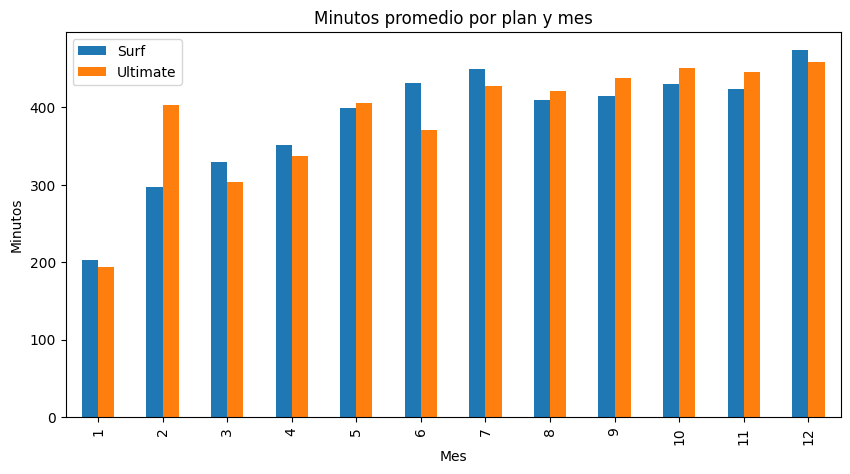

In [52]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

calls_by_month_avg = itemized_bill.pivot_table(
    index='month', columns='plan_name', values='minutes_used', aggfunc='mean'
)

calls_by_month_avg.plot(kind='bar', figsize=(10, 5))
plt.title('Minutos promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Minutos')
plt.legend(['Surf', 'Ultimate'])
plt.show()

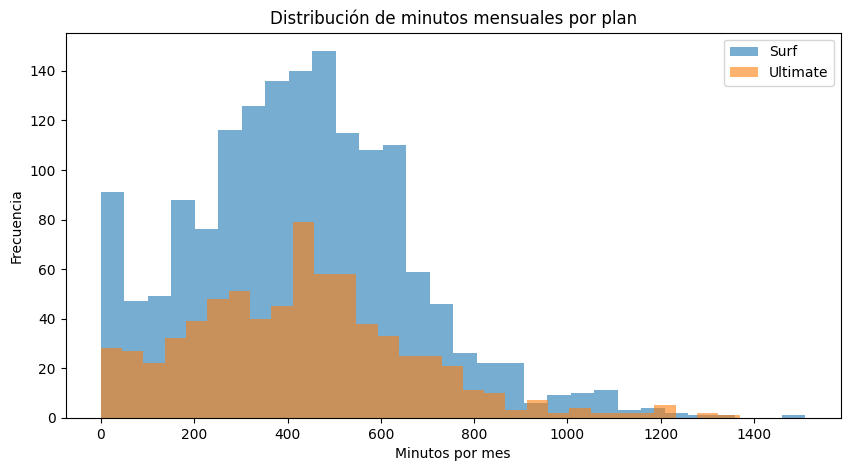

In [53]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

calls_plan_surf= itemized_bill[itemized_bill['plan_name'] == 'surf']['minutes_used']
calls_plan_ultimate = itemized_bill[itemized_bill['plan_name'] == 'ultimate']['minutes_used']

plt.figure(figsize=(10, 5))
plt.hist(calls_plan_surf, bins=30, alpha=0.6, label='Surf')
plt.hist(calls_plan_ultimate, bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos por mes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [54]:
# Calcula la media y la varianza de la duracion mensual de llamadas.

# Estadisticas agregadas por plan
print('Minutos por plan (todos los meses):')
display(itemized_bill.groupby('plan_name')['minutes_used'].agg(['mean', 'var', 'std', 'count']))

# Estadisticas mes a mes por plan
print()
print('Minutos por plan y por mes:')
display(itemized_bill.groupby(['plan_name', 'month'])['minutes_used']
        .agg(['mean', 'var', 'std', 'count']).round(2))


Minutos por plan (todos los meses):


,mean,var,std,count
plan_name,,,,
surf,428.749523,54968.279461,234.453150,1573
ultimate,430.450000,57844.464812,240.508762,720



Minutos por plan y por mes:


mean       var     std  count
plan_name month                                 
surf      1      203.00  15842.00  125.87      2
          2      297.00  52226.50  228.53      9
          3      330.00  35809.36  189.23     23
          4      351.54  50866.74  225.54     50
          5      399.58  59754.22  244.45     77
          6      431.30  45592.63  213.52     97
          7      449.98  61005.10  246.99    121
          8      410.11  54344.65  233.12    162
          9      414.23  46595.96  215.86    194
          10     429.73  52278.66  228.65    237
          11     423.33  51607.02  227.17    283
          12     473.84  63629.52  252.25    318
ultimate  1      193.50  16572.33  128.73      4
          2      403.14  76889.48  277.29      7
          3      304.25  61984.93  248.97     12
          4      336.86  34888.93  186.79     21
          5      406.24  43841.05  209.38     29
          6      370.96  42503.56  206.16     47
          7      427.07  72563.37  269.38     59
          8      421.44  53645.51  231.61     71
          9      437.51  57070.46  238.89     86
          10     450.74  54261.91  232.94    106
          11     445.20  60593.22  246.16    127
          12     459.10  62503.78  250.01    151

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Calculaste la media/varianza por plan combinando todos los meses, pero esta tarea pide estadísticas de duración de llamadas *mensuales*. Considera calcularlas tanto por plan como por mes (p. ej., agrupar por `['plan_name', 'month']`) para que la comparación refleje el comportamiento mes a mes.

</div>


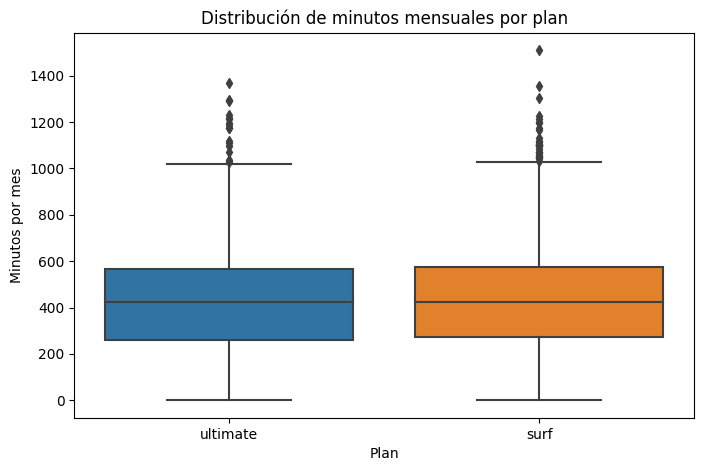

In [55]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(8, 5))
sns.boxplot(data=itemized_bill, x='plan_name', y='minutes_used')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos por mes')
plt.show()

In [56]:
itemized_bill['minutes_exceded'] = itemized_bill['minutes_used'] > itemized_bill['minutes_included']

(itemized_bill.groupby('plan_name')['minutes_exceded'].mean() * 100).round(1)

plan_name
surf        36.0
ultimate     0.0
Name: minutes_exceded, dtype: float64

- Los usuarios de ambos planes tienen comportamientos similares. Se puede ver en la media de cada uno $Surf = 428.74$ vs $Ultimate = 430.45$
- A partir del histograma podemos ver que ambos planes tienen un sesgo hacia la derecha, mostrando consumos que superan los 1,000 minutos al mes. El diagrama de cajas los muestra como valores atípicos, destacando que el consumo para ambos planes se localiza entre los 200 - 600 minutos al mes.
- El plan tiene asignados 500 minutos mensuales, pero se ve que el consumo de los usuarios excede este límite llegando a cantidades por encima de los 1,000 minutos al mes. En cambio, ese mismo consumo en el plan Ultimate está muy por debajo de los 3,000 minutos base del plan. En resumen, los usuarios del plan Surf están generando ganancias adicionales a diferencia de los usuarios de Ultimate que solamente están consumiendo los minutos de su plan.
- El 36% de los usuarios-mes del plan Surf exceden su límite de 500 minutos. Por otra parte, el 0% de los usuarios de Ultimate exceden su límite de 3,000 minutos.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial. Tus histogramas muestran claramente la diferencia temporal de comportamiento de cada uno de los planes respecto a la duración de las llamadas y la tendencia de minutos usados al mes por plan. Excelente análisis frente a la media y las desviaciones de la duracion de las llamadas por cada plan, como mencionas, esta diferencia no es muy significativa y esto es un dato valioso. 


### Mensajes

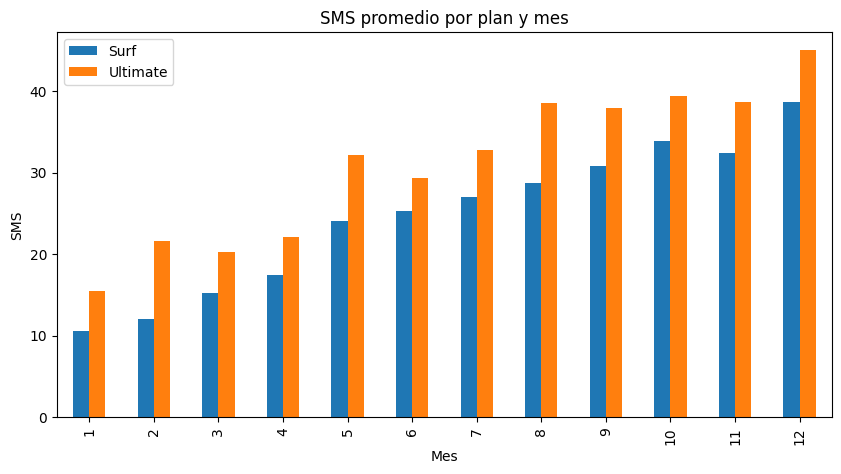

In [57]:
# Compara la cantidad promedio de mensajes por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

messages_by_month_avg = itemized_bill.pivot_table(
    index='month', columns='plan_name', values='messages_count', aggfunc='mean'
)

messages_by_month_avg.plot(kind='bar', figsize=(10, 5))
plt.title('SMS promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('SMS')
plt.legend(['Surf', 'Ultimate'])
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La agregación requerida del recuento mensual de llamadas en realidad ya aparece antes (creaste `calls_by_user`). Este comentario se puede ignorar: tu sección de “Messages” está alineada con su tarea.

</div>


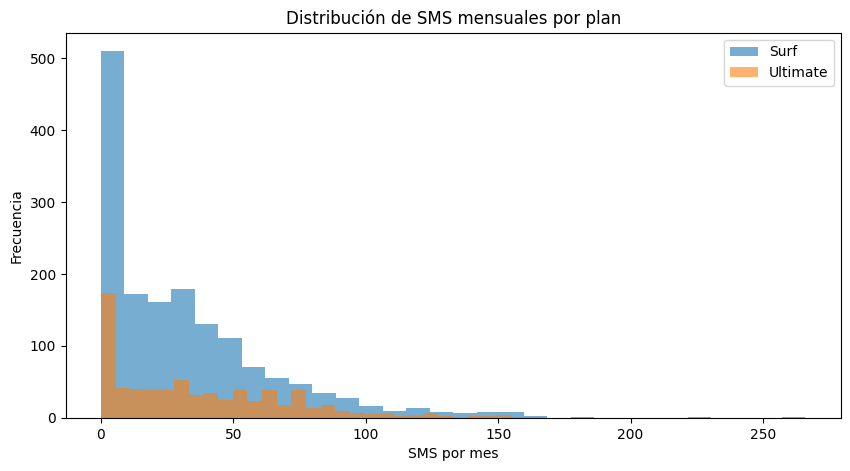

In [58]:
# Compara el número de mensajes mensuales que necesitan los usuarios de cada plan. Traza un histograma.

messages_plan_surf= itemized_bill[itemized_bill['plan_name'] == 'surf']['messages_count']
messages_plan_ultimate = itemized_bill[itemized_bill['plan_name'] == 'ultimate']['messages_count']

plt.figure(figsize=(10, 5))
plt.hist(messages_plan_surf, bins=30, alpha=0.6, label='Surf')
plt.hist(messages_plan_ultimate, bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de SMS mensuales por plan')
plt.xlabel('SMS por mes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [59]:
# Calcula la media y la varianza de los mensajes al mes.

itemized_bill.groupby('plan_name')['messages_count'].agg(['mean', 'var', 'std', 'count'])

,mean,var,std,count
plan_name,,,,
surf,31.159568,1126.724522,33.566717,1573
ultimate,37.551389,1208.756744,34.767179,720


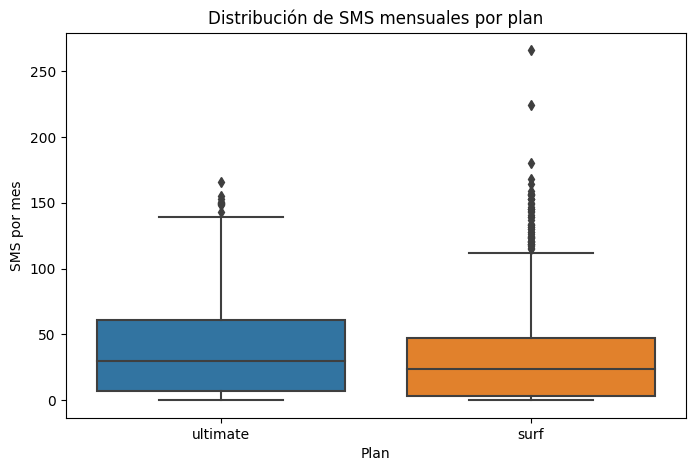

In [60]:
# Traza un diagrama de caja para visualizar la distribución de mensajes mensuales

plt.figure(figsize=(8, 5))
sns.boxplot(data=itemized_bill, x='plan_name', y='messages_count')
plt.title('Distribución de SMS mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('SMS por mes')
plt.show()

In [61]:
itemized_bill['messages_exceded'] = itemized_bill['messages_count'] > itemized_bill['messages_included']

(itemized_bill.groupby('plan_name')['messages_exceded'].mean() * 100).round(1)

plan_name
surf        21.6
ultimate     0.0
Name: messages_exceded, dtype: float64

- Los usuarios de ambos planes tienen comportamientos diferentes. Se puede ver en la media de cada uno $Surf = 31.15$ vs $Ultimate = 37.55$, mostrando que los usuarios de Ultimate tienen un mayor consumo mensual.
- A partir del histograma podemos ver que ambos planes tienen un sesgo hacia la derecha, mostrando consumos que superan los 120 mensajes al mes. El diagrama de cajas los muestra como valores atípicos, destacando que el consumo para ambos planes se localiza entre los 5 - 60 mensajes al mes.
- El plan Surf tiene asignados 50 mensajes mensuales, pero se ve que el consumo de los usuarios excede este límite llegando a cantidades por encima de los 120 mensajes al mes. En cambio, ese mismo consumo en el plan Ultimate está muy por debajo de los 1,000 mensajes base del plan. Aunque los usuarios de Ultimate usan más el servicio, son los que menos pagan por él, a diferencia de los usuarios de Surf.
- El 21.6% de los usuarios-mes del plan Surf exceden su límite de 50 mensajes. Por otra parte, el 0% de los usuarios de Ultimate exceden su límite de 1,000 mensajes.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen análisis del comportamiento de mensajería: combinaste promedios mensuales, gráficos de distribución y estadísticas resumen, y tu narrativa conecta claramente las visualizaciones con la conclusión clave.

</div>


### Internet

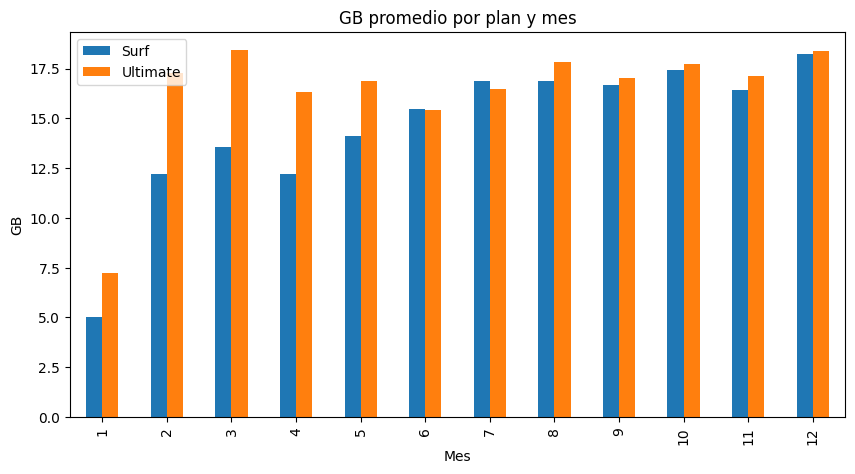

In [62]:
# Compara la cantidad promedio de gb por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

gb_by_month_avg = itemized_bill.pivot_table(
    index='month', columns='plan_name', values='gb_used', aggfunc='mean'
)

gb_by_month_avg.plot(kind='bar', figsize=(10, 5))
plt.title('GB promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('GB')
plt.legend(['Surf', 'Ultimate'])
plt.show()

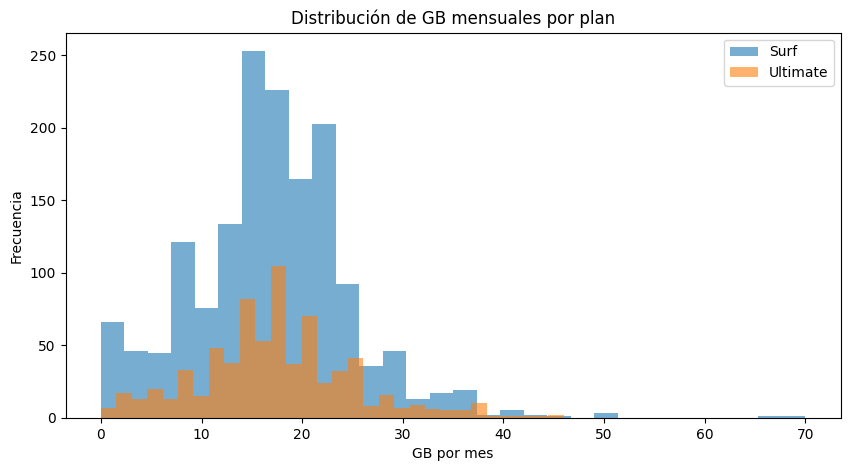

In [63]:
# Compara la cantidad de GB mensuales que necesitan los usuarios de cada plan. Traza un histograma.

gb_plan_surf= itemized_bill[itemized_bill['plan_name'] == 'surf']['gb_used']
gb_plan_ultimate = itemized_bill[itemized_bill['plan_name'] == 'ultimate']['gb_used']

plt.figure(figsize=(10, 5))
plt.hist(gb_plan_surf, bins=30, alpha=0.6, label='Surf')
plt.hist(gb_plan_ultimate, bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de GB mensuales por plan')
plt.xlabel('GB por mes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [64]:
# Calcula la media y la varianza de los gb al mes.

itemized_bill.groupby('plan_name')['gb_used'].agg(['mean', 'var', 'std', 'count'])

,mean,var,std,count
plan_name,,,,
surf,16.670693,61.58360,7.847522,1573
ultimate,17.306944,58.83055,7.670108,720


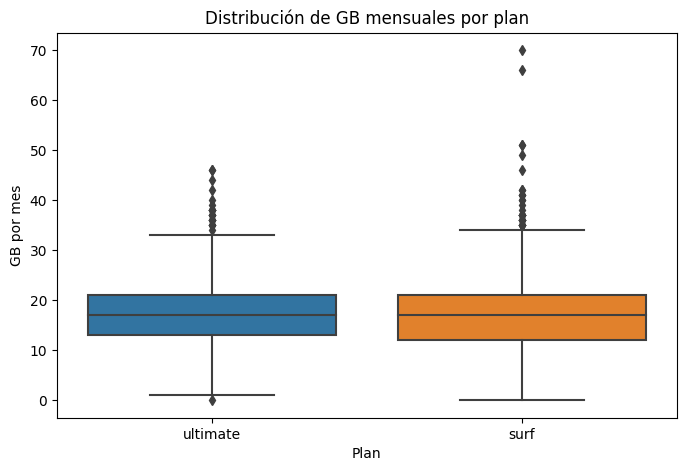

In [65]:
# Traza un diagrama de caja para visualizar la distribución de las gb mensuales

plt.figure(figsize=(8, 5))
sns.boxplot(data=itemized_bill, x='plan_name', y='gb_used')
plt.title('Distribución de GB mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('GB por mes')
plt.show()

In [66]:
itemized_bill['gb_exceded'] = itemized_bill['gb_used'] > itemized_bill['gb_per_month_included']

(itemized_bill.groupby('plan_name')['gb_exceded'].mean() * 100).round(1)

plan_name
surf        57.9
ultimate     5.7
Name: gb_exceded, dtype: float64

- Los usuarios de ambos planes tienen comportamientos similares. Se puede ver en la media de cada uno $Surf = 16.67$ vs $Ultimate = 17.3$, mostrando que los usuarios de Ultimate tienen un mayor consumo mensual y que los usuarios de Surf están superando el límite mensual.
- A partir del histograma podemos ver que ambos planes tienen un sesgo hacia la derecha, mostrando consumos que superan los 30 GB al mes. El diagrama de cajas los muestra como valores atípicos, destacando que el consumo para ambos planes se localiza entre los 12 - 22 GB al mes.
- El plan Surf tiene asignados 15 GB mensuales, pero se ve que el consumo de los usuarios excede este límite llegando a cantidades por encima de los 20 GB al mes. Por otra parte, los usuarios de Ultimate con una asignación mensual de 30 GB, se ve que también tienen consumos extra que llegan hasta los 45 GB al mes.
- El 57.9% de los usuarios-mes del plan Surf exceden su límite de 15 GB, mientras que el 5.7% de los usuarios de Ultimate exceden su límite de 30 GB.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Bien, comparación completa del uso de internet: estadísticas descriptivas más histograma/boxplot y una conclusión clara sobre la similitud entre los planes.

</div>


### Ingreso

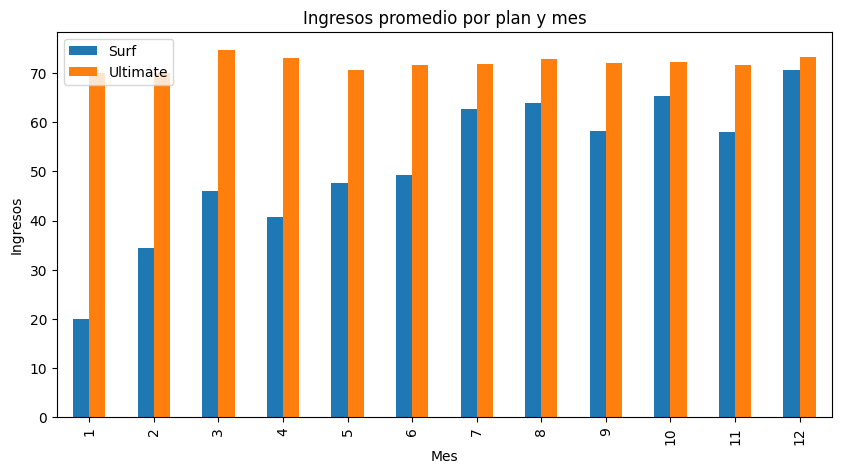

In [67]:
# Compara los ingresos promedio por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

revenue_by_month_avg = itemized_bill.pivot_table(
    index='month', columns='plan_name', values='revenue', aggfunc='mean'
)

revenue_by_month_avg.plot(kind='bar', figsize=(10, 5))
plt.title('Ingresos promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.legend(['Surf', 'Ultimate'])
plt.show()

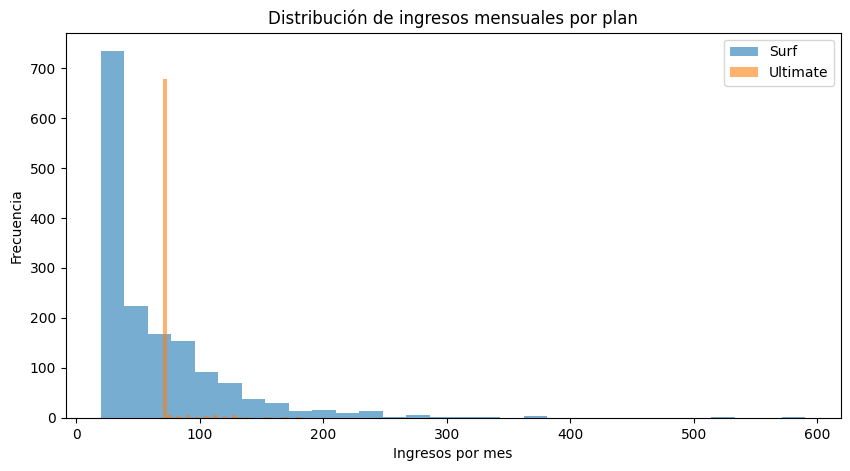

In [68]:
# Compara los ingresos mensuales que realizan los usuarios de cada plan. Traza un histograma.

revenue_plan_surf= itemized_bill[itemized_bill['plan_name'] == 'surf']['revenue']
revenue_plan_ultimate = itemized_bill[itemized_bill['plan_name'] == 'ultimate']['revenue']

plt.figure(figsize=(10, 5))
plt.hist(revenue_plan_surf, bins=30, alpha=0.6, label='Surf')
plt.hist(revenue_plan_ultimate, bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingresos por mes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [69]:
# Calcula la media y la varianza de los ingresos al mes.

itemized_bill.groupby('plan_name')['revenue'].agg(['mean', 'median', 'var', 'std', 'count'])

,mean,median,var,std,count
plan_name,,,,,
surf,60.706408,40.36,3067.835152,55.388042,1573
ultimate,72.313889,70.00,129.848486,11.395108,720


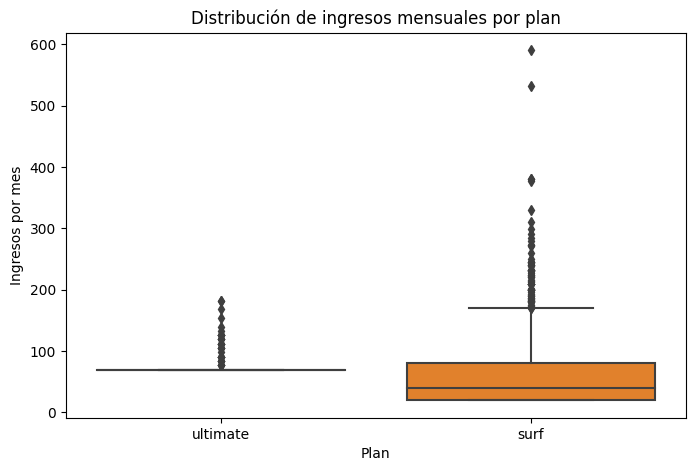

In [70]:
# Traza un diagrama de caja para visualizar la distribución de los ingresos mensuales

plt.figure(figsize=(8, 5))
sns.boxplot(data=itemized_bill, x='plan_name', y='revenue')
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingresos por mes')
plt.show()

In [71]:
itemized_bill['revenue_exceded'] = itemized_bill['revenue'] > itemized_bill['usd_monthly_fee']

(itemized_bill.groupby('plan_name')['revenue_exceded'].mean() * 100).round(1)

plan_name
surf        72.6
ultimate     5.7
Name: revenue_exceded, dtype: float64

- Los usuarios de ambos planes tienen comportamientos radicalmente diferentes. Se puede ver en la media de cada uno $Surf = 60.7$ vs $Ultimate = 72.31$, mostrando que los usuarios de Ultimate se mantienen bastante cerca de su tarifa base de $70, mientras que los usuarios de Surf superan la tarifa base de $20.
- Según la mediana, más de la mitad de los usuarios del plan Surf facturan menos de $40. El promedio se ve afectado por consumos mensuales más altos, $avg= 60.7$
- Los usuarios del plan Ultimate generan un mayor ingreso mensual pese a que no exceden la tarifa base. En cambio, los usuarios de Surf generan un ingreso menor pero exceden su tarifa base.
- El plan Surf tiene un costo base de $20 pero se ve que generan ingresos superiores que van desde los $20 hasta los $300. Por otra parte, los usuarios de Ultimate tienen una facturación más predecible, teniendo muy poca variación respecto a la tarifa base de $70. σ = 55.39 (Surf) vs 11.40 (Ultimate)
- El 72.6% de los usuarios-mes del plan Surf exceden su tarifa base de $20 mensuales, mientras que el 5.7% de los usuarios de Ultimate exceden la tarifa base de $70 mensuales.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Excelente sección de ingresos: cuantificas tanto la diferencia de medias como la variabilidad mucho mayor de Surf, y tu interpretación coincide con lo que muestran los gráficos y las estadísticas.

</div>


## Prueba las hipótesis estadísticas

### Hipotesis 1: el ingreso promedio difiere entre los planes Surf y Ultimate

H₀: El ingreso promedio de los usuarios del plan Surf es igual al de los usuarios del plan Ultimate.

H₁: El ingreso promedio de los usuarios del plan Surf es distinto al de los usuarios del plan Ultimate.

- Como el enunciado dice "diferente", no "mayor", no se establece ninguna dirección por lo que el tipo de prueba es de dos colas.
- Como estamos comparando las medias de dos grupos independientes (un usuario no puede pertenecer a los dos planes a la vez), aplicamos una prueba t para dos muestras independientes `st.ttest_ind()`
- Como valor de alfa, elijo 0.05 como la probabilidad de rechazar H₀ siendo verdadera. Es decir que, acepta un 5% de riesgo de detectar una diferencia que no existe.
- Del análisis anterior, noté que las desviaciones estándar son diferentes σ = 55.39 en Surf vs 11.40 en Ultimate, debo fijarme en el parámetro `equal_var` ya que por defecto es True asumiendo que las desviaciones son iguales.
- **Regla de decision:** si $p < \alpha$ rechazamos $H_0$ y concluimos que existe evidencia de una diferencia entre las medias. Si $p \geq \alpha$ no podemos rechazar $H_0$, lo que no equivale a demostrar que las medias sean iguales.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus hipótesis y la elección de la prueba están bien explicadas. Para mayor completitud, conviene añadir una declaración explícita de la regla de decisión (por ejemplo, cómo comparas el p-value con alpha) inmediatamente antes de interpretar el resultado de la prueba, de modo que la conclusión quede claramente vinculada al criterio.

</div>


In [72]:
# Prueba las hipótesis

alpha = 0.05

revenue_plan_surf= itemized_bill[itemized_bill['plan_name'] == 'surf']['revenue']
revenue_plan_ultimate = itemized_bill[itemized_bill['plan_name'] == 'ultimate']['revenue']

result = st.ttest_ind(revenue_plan_surf, revenue_plan_ultimate, equal_var=False)
print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

p-value: 3.1703905481135734e-15
Rechazamos la hipótesis nula


- El p-valor obtenido es $p = 3.17 \times 10^{-15}$, muy por debajo del alfa de $0.05$, por lo que rechazamos la hipótesis nula. Existe evidencia estadística de que el ingreso promedio mensual difiere entre ambos planes.
- La diferencia va a favor de Ultimate: $Surf = 60.71$ vs $Ultimate = 72.31$, es decir $11.61$ dólares más por usuario-mes. Aunque los usuarios de Surf exceden sus límites con mucha frecuencia, los cargos adicionales no alcanzan a compensar los $50 de diferencia en la tarifa base.
- Un p-valor tan pequeño indica que es muy improbable observar esta diferencia si las medias fueran iguales, pero no dice nada sobre su tamaño. La magnitud la da la diferencia de $11.61, y en este caso ambas cosas resultan relevantes para el negocio.
- Usé `equal_var=False` porque las desviaciones estándar son muy distintas, $σ_{Surf} = 55.39$ vs $σ_{Ultimate} = 11.40$.

### Hipotesis 2: el ingreso promedio del area NY-NJ difiere del de otras regiones

In [73]:
itemized_bill.groupby('is_ny_nj')['revenue'].agg(['mean', 'median', 'var', 'std', 'count'])

,mean,median,var,std,count
is_ny_nj,,,,,
False,65.222771,70.00,2225.047994,47.170414,1916
True,59.921353,51.77,1895.545690,43.537865,377


In [74]:
itemized_bill.groupby('is_ny_nj')['plan_name'].value_counts(normalize=True) * 100

is_ny_nj  plan_name
False     surf         65.814196
          ultimate     34.185804
True      surf         82.758621
          ultimate     17.241379
Name: plan_name, dtype: float64

In [75]:
itemized_bill.groupby(['plan_name', 'is_ny_nj'])['revenue'].agg(['mean', 'count'])

mean  count
plan_name is_ny_nj                  
surf      False     61.675519   1261
          True      56.789583    312
ultimate  False     72.051908    655
          True      74.953846     65

H₀: El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

H₁: El ingreso promedio de los usuarios del área NY-NJ es distinto al de los usuarios de otras regiones.

- Como el enunciado dice "diferente", no "mayor", no se establece ninguna dirección por lo que el tipo de prueba es de dos colas.
- Como estamos comparando las medias de dos grupos independientes (un usuario no puede vivir en las dos áreas a la vez), aplicamos una prueba t para dos muestras independientes `st.ttest_ind()`
- Como valor de alfa, elijo 0.05 como la probabilidad de rechazar H₀ siendo verdadera. Es decir que, acepta un 5% de riesgo de detectar una diferencia que no existe.
- Del cálculo anterior, noté que las desviaciones estándar son similares σ = 43.53 en NY vs 47.17 en otras regiones, debo fijarme en el parámetro `equal_var` y dejarlo en True ya que las desviaciones son muy cercanas.
- **Definicion del grupo NY-NJ:** se clasifica como NY-NJ todo usuario cuya columna `city` sea exactamente `'New York-Newark-Jersey City, NY-NJ-PA MSA'`, la etiqueta del area metropolitana que el proyecto solicita. Se descarto filtrar por el texto `'NY'` porque tambien capturaba `Buffalo-Cheektowaga, NY MSA`, `Rochester, NY MSA` y `Albany-Schenectady-Troy, NY MSA`, que pertenecen al estado de Nueva York pero no al area metropolitana. El criterio deja 80 de los 500 usuarios en el grupo NY-NJ; tras excluir a los 10 sin actividad, la comparacion se hace sobre 80 usuarios NY-NJ y 410 del resto de regiones.
- **Regla de decision:** si $p < \alpha$ rechazamos $H_0$; si $p \geq \alpha$ no podemos rechazarla.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Dado que esta prueba de hipótesis depende en gran medida de cómo se define el grupo NY–NJ, considera reformular brevemente la regla exacta que usaste para clasificar `city` como NY–NJ y confirmar que coincide con la definición del proyecto, para que el resultado sea interpretable y reproducible.

</div>


In [76]:
# Prueba las hipótesis

alpha = 0.05

revenue_ny = itemized_bill[itemized_bill['is_ny_nj']]['revenue']
revenue_others = itemized_bill[~itemized_bill['is_ny_nj']]['revenue']

result = st.ttest_ind(revenue_ny, revenue_others, equal_var=True)
print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

p-value: 0.043557431621342436
Rechazamos la hipótesis nula


- El p-valor obtenido es $p = 0.0436$, por debajo del alfa de $0.05$, por lo que rechazamos la hipótesis nula. El área NY-NJ factura en promedio $59.92$ contra $65.22$ del resto de regiones, es decir $5.30$ menos por usuario-mes.
- A diferencia de la primera prueba, este resultado es marginal. Con un alfa de $0.01$ no habríamos podido rechazar la hipótesis nula, por lo que la conclusión depende del nivel de significancia elegido y no de una diferencia contundente en los datos.
- Se usó `equal_var=True` porque las desviaciones estándar de ambos grupos son similares, $σ_{NY} = 43.54$ vs $σ_{otros} = 47.17$.
- La mediana muestra una brecha mayor que la media: $51.77$ en NY-NJ contra $70.00$ en el resto. Ese $70.00$ coincide exactamente con la tarifa base de Ultimate, lo que sugiere que la diferencia tiene que ver con qué planes se contratan en cada región.
- En NY-NJ el $82.8\%$ de los usuario-mes son de Surf, frente al $65.8\%$ en el resto del país. Como Surf factura menos en promedio, parte de la diferencia regional se explica por la mezcla de planes y no por la región en sí.
- Al comparar dentro de cada plan, el efecto regional deja de ser consistente: en Surf los usuarios de NY-NJ facturan menos ($56.79$ vs $61.68$), pero en Ultimate facturan más ($74.95$ vs $72.05$). Las diferencias van en direcciones opuestas, lo que refuerza que el resultado global responde a un efecto de composición.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente uso de `ttest_ind` de scipy para tus pruebas de hipotesis. Has conseguido llegar a la conclusion esperada y demostrar con claridad la diferencia entre los planes de telefonia. 

## Conclusion general

- Las cuatro tablas traían las fechas como texto, por lo que se convirtieron a `datetime` para poder extraer el mes y agregar el consumo por periodo. También verifiqué que todos los registros correspondan a 2018.
- Los límites de datos venían en megabytes mientras que los precios de excedente están en gigabytes, por lo que se creé la columna `gb_per_month_included` usando la equivalencia $1\ GB = 1024\ MB$ indicada en el enunciado.
- Las llamadas con duración $0$ no se eliminaron, pero las omití del conteo de llamadas.
- Para identificar el área NY-NJ se filtró por `New York` para obtener los $80$ usuarios del área.
- **Llamadas:** el consumo es prácticamente idéntico entre planes ($Surf = 428.75$ vs $Ultimate = 430.45$ minutos). Sin embargo, el $36.0\%$ de los usuario-mes de Surf excede sus $500$ minutos incluidos, frente al $0.0\%$ de Ultimate. Ningún usuario de Ultimate se acercó a sus $3,000$ minutos en todo el año.
- **Mensajes:** aquí sí hay diferencia de comportamiento, y a favor de Ultimate ($37.55$ vs $31.16$ SMS). Aun así, el $21.6\%$ de los usuario-mes de Surf excede su límite de $50$ mensajes, mientras que ninguno de Ultimate se acerca a sus $1,000$. El grupo que más usa el servicio es el que menos paga por usarlo.
- **Internet:** el consumo es similar entre planes ($16.67$ vs $17.31$ GB), pero el promedio general está **por encima** del límite de $15$ GB de Surf. Por eso el $57.9\%$ de sus usuario-mes genera cargo por datos, el porcentaje más alto de las tres métricas. En Ultimate también se excede, aunque solo en el $5.7\%$ de los casos.
- Los datos son la razón principal de los ingresos variables de Surf: además de ser la métrica que más se excede, cada GB adicional cuesta $10 frente a los $0.03 del minuto o del mensaje.
- El plan Ultimate genera un mayor ingreso promedio por usuario-mes: $72.31$ contra $60.71$ de Surf.
- El plan Ultimate tiene facturaciones más predecibles, casi siempre iguales a su tarifa base mientras que el plan Surf produce facturas que van desde los $20 hasta los $300.
- La mediana de Surf ($40.36$) está muy por debajo de su media ($60.71$), lo que indica que más de la mitad de sus usuario-mes facturan poco más que la cuota base y que el promedio lo elevan unos pocos meses de consumo alto. En Ultimate media y mediana casi coinciden ($72.31$ vs $70.00$).
- El $72.6\%$ de los usuario-mes del plan Surf paga por encima de su tarifa base, frente al $5.7\%$ del plan Ultimate.
- **Por usuario, el plan Ultimate tiene la tarifa más rentable:** genera $11.61$ más al mes y con ingresos mucho más estables y predecibles.
- El plan Surf aporta más ingreso total a la empresa ($95,491$ frente a $52,066$, aproximadamente el $65\%$ del total), simplemente porque tiene más usuarios-mes.
- Siguiendo el objetivo de orientar el presupuesto publicitario, la métrica relevante es el ingreso por usuario por lo que se recomienda dirigir la publicidad hacia el plan Ultimate.**
- El plan Ultimate ofrece además una ventaja para la planeación financiera: sus ingresos son casi fijos, mientras que los de Surf dependen de excedentes que varían mucho mes a mes.